# GCGA Genetic Algorithm 진행 추이 시각화

`../03_gcga/gcga.db` 의 ASE database 로부터 부모/자식 세대 에너지 정보를 읽어 GA 의 진행 추이를 그립니다.

- **kid index (generation)** : 자식이 생성된 순서 (`s00XXXX` 의 번호)
- **eV** : potential energy
- **grandPot** : grand potential (GCGA 의 fitness 기준)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
from ase.db import connect

# 1. 전역 스타일 테마 적용
plt.style.use(["science", "notebook"])

# 2. 전역 파라미터 통합 설정
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.family': 'Arial',
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'legend.fontsize': 18,
    'legend.frameon': True,
    'lines.linewidth': 3.5,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
print('✅ Matplotlib 전역 스타일 통일 설정 완료!')

✅ Matplotlib 전역 스타일 통일 설정 완료!


In [2]:
# --- DB 로드 ---
DB_PATH = '../03_gcga/process/gcga.db'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

db = connect(DB_PATH)

parent_E, parent_GP = [], []
kid_idx, kid_E, kid_GP = [], [], []

for row in db.select():
    name = row.name
    if name.startswith('parent'):
        parent_E.append(row.eV)
        parent_GP.append(row.grandPot)
    elif name.startswith('s') and name[1:].isdigit():
        kid_idx.append(int(name[1:]))
        kid_E.append(row.eV)
        kid_GP.append(row.grandPot)

parent_E  = np.asarray(parent_E)
parent_GP = np.asarray(parent_GP)

# kid 는 생성순으로 정렬
order = np.argsort(kid_idx)
kid_idx = np.asarray(kid_idx)[order]
kid_E   = np.asarray(kid_E)[order]
kid_GP  = np.asarray(kid_GP)[order]

# 누적 최저 에너지 (parent 까지 포함한 전체 최저값을 기준으로)
init_min_E  = parent_E.min()
init_min_GP = parent_GP.min()
cum_min_E   = np.minimum.accumulate(np.concatenate([[init_min_E],  kid_E ]))[1:]
cum_min_GP  = np.minimum.accumulate(np.concatenate([[init_min_GP], kid_GP]))[1:]

print(f'부모 개수 : {len(parent_E)}')
print(f'자식 개수 : {len(kid_E)}')
print(f'부모 최저 E   : {parent_E.min():.3f} eV')
print(f'자식 최저 E   : {kid_E.min():.3f} eV')
print(f'부모 최저 GP  : {parent_GP.min():.3f} eV')
print(f'자식 최저 GP  : {kid_GP.min():.3f} eV')

부모 개수 : 50
자식 개수 : 179
부모 최저 E   : -3933.721 eV
자식 최저 E   : -4285.971 eV
부모 최저 GP  : -102.728 eV
자식 최저 GP  : -186.128 eV


## 1. 세대에 따른 에너지 변화

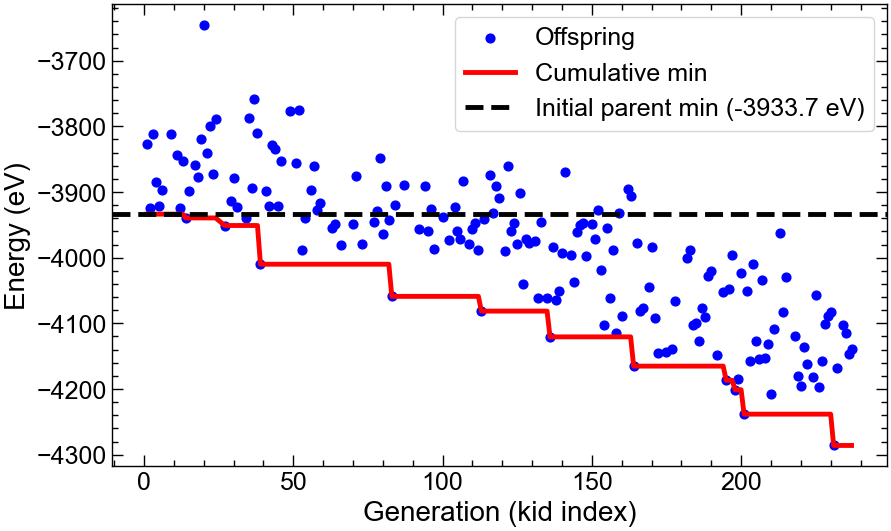

In [3]:
fig, ax = plt.subplots()

ax.scatter(kid_idx, kid_E, s=40, color='blue', label='Offspring') #alpha=0.6 edgecolor='none',
ax.plot(kid_idx, cum_min_E, color='red', label='Cumulative min')
ax.axhline(parent_E.min(), color='k', ls='--', label=f'Initial parent min ({parent_E.min():.1f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Energy (eV)')
# ax.set_title('Energy vs. Generation')
ax.legend(loc='upper right')#, fontsize=14)
# ax.minorticks_on()
# ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.savefig(os.path.join(FIG_DIR, '01_energy_vs_generation.png'))
plt.show()

## 2. 부모세대 vs 자식세대 에너지 분포

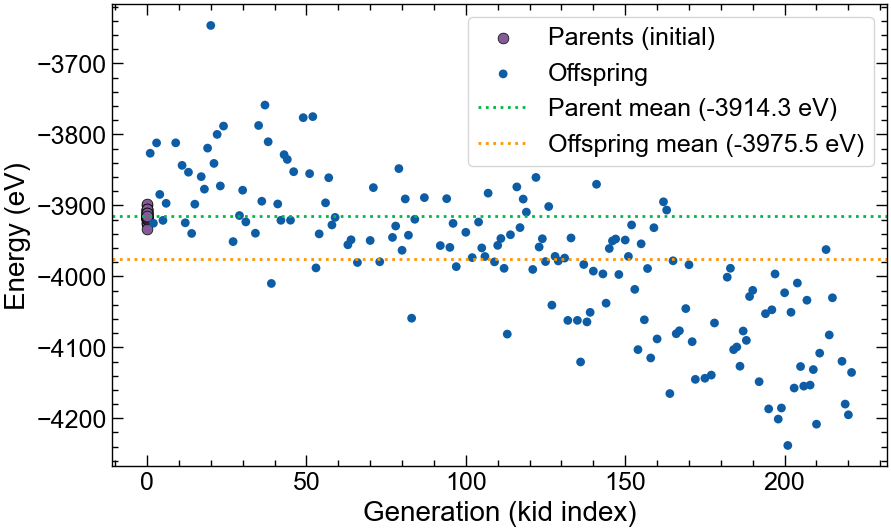

In [7]:
fig, ax = plt.subplots()

# 부모 : x = 0 영역에 산점
parent_x = np.zeros_like(parent_E)
ax.scatter(parent_x, parent_E,
           s=60, color='C4',
           edgecolor='k', linewidth=0.5, label='Parents (initial)')

# 자식 : 실제 생성 순서대로
ax.scatter(kid_idx, kid_E,
           s=40, color='C0',
           edgecolor='none', label='Offspring')

# 부모/자식 평균 라인
ax.axhline(parent_E.mean(), color='C1', ls=':', lw=2,
           label=f'Parent mean ({parent_E.mean():.1f} eV)')
ax.axhline(kid_E.mean(), color='C2', ls=':', lw=2,
           label=f'Offspring mean ({kid_E.mean():.1f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Energy (eV)')
# ax.set_title('Parents vs. Offspring')
ax.legend(loc='upper right')#, fontsize=13)
ax.minorticks_on()

plt.savefig(os.path.join(FIG_DIR, '02_parents_vs_offspring.png'))
plt.show()

## 3. Total minimum energy

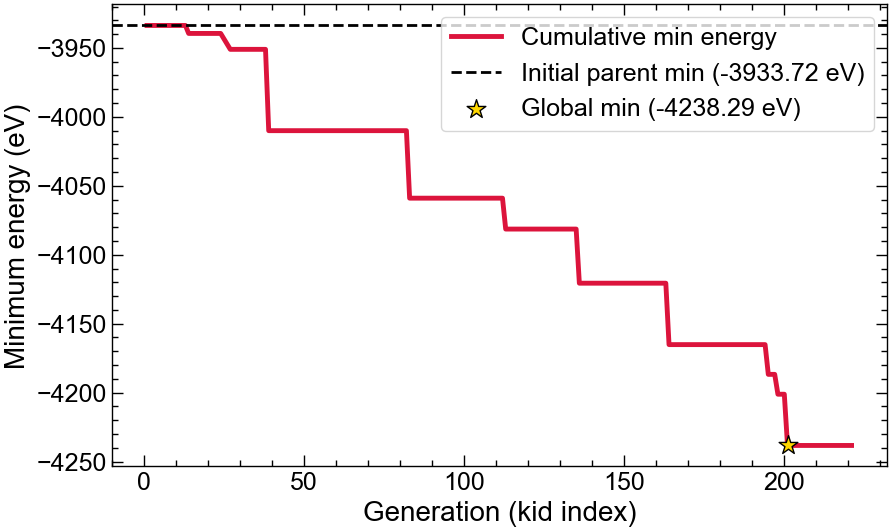

In [8]:
fig, ax = plt.subplots()

ax.plot(kid_idx, cum_min_E,
        color='crimson', lw=3.5, label='Cumulative min energy')
ax.axhline(parent_E.min(), color='k', ls='--', lw=2,
           label=f'Initial parent min ({parent_E.min():.2f} eV)')
ax.scatter([kid_idx[np.argmin(kid_E)]], [kid_E.min()],
           s=200, marker='*', color='gold', edgecolor='k',
           zorder=5, label=f'Global min ({kid_E.min():.2f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Minimum energy (eV)')
# ax.set_title('Total Minimum Energy Progression')
ax.legend(loc='upper right')#, fontsize=13)
ax.minorticks_on()

plt.savefig(os.path.join(FIG_DIR, '03_total_min_energy.png'))
plt.show()

## 4. (선택) Grand Potential 기준 동일 플롯

GCGA 의 자연 선택은 `grandPot` 을 기준으로 이루어지므로, 동일한 시각화를 GP 기준으로 한 번 더 그립니다.

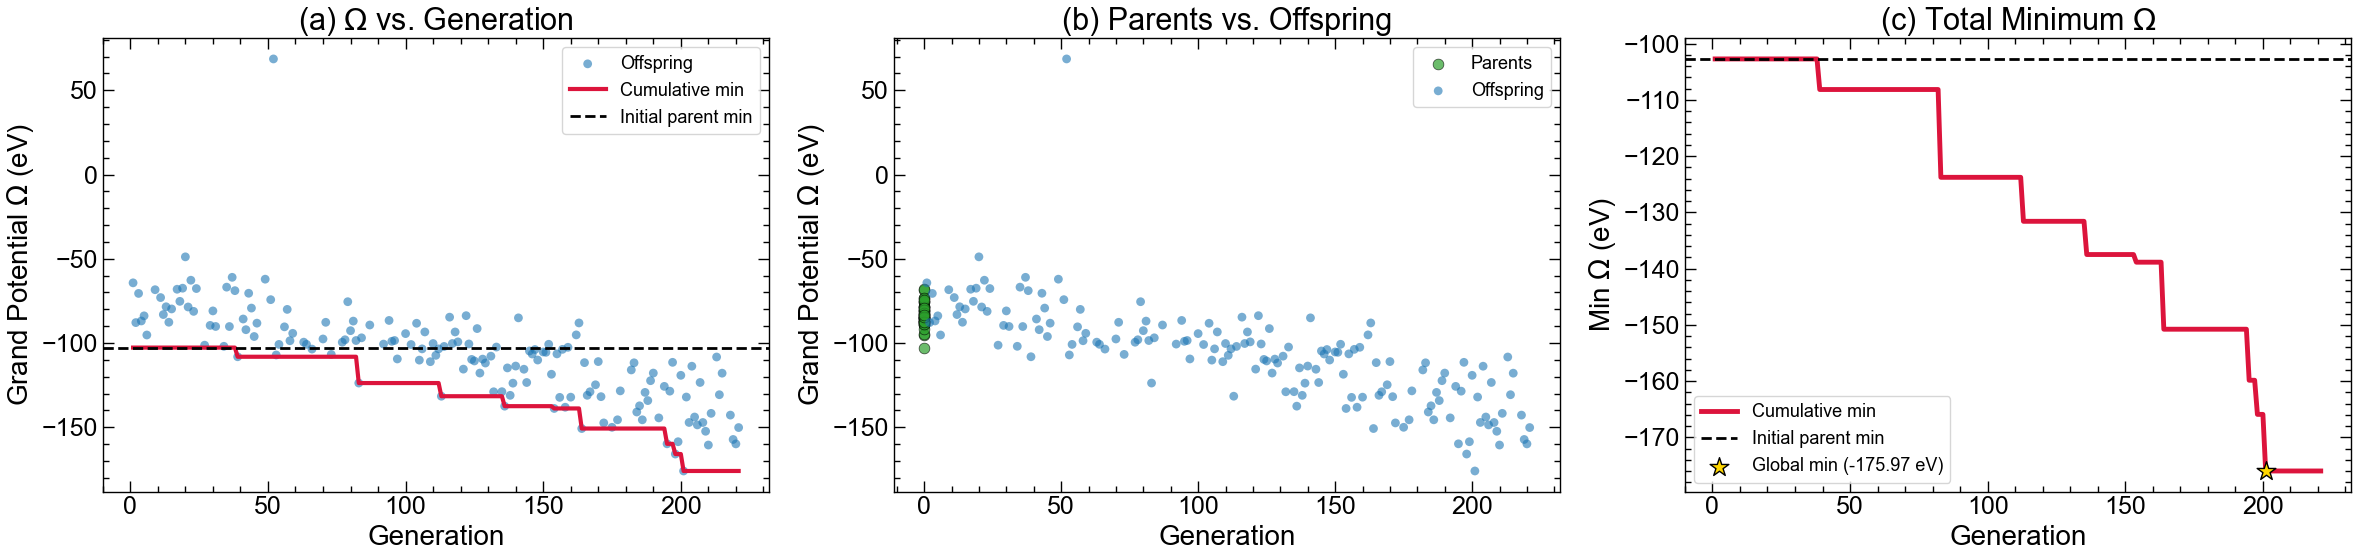

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# (a) GP vs generation
ax = axes[0]
ax.scatter(kid_idx, kid_GP, s=40, color='#1f77b4', alpha=0.6,
           edgecolor='none', label='Offspring')
ax.plot(kid_idx, cum_min_GP, color='crimson', lw=3.0, label='Cumulative min')
ax.axhline(parent_GP.min(), color='k', ls='--', lw=2, label='Initial parent min')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Grand Potential $\Omega$ (eV)')
ax.set_title('(a) $\\Omega$ vs. Generation')
ax.legend(fontsize=13)
ax.minorticks_on()

# (b) Parent vs Kid
ax = axes[1]
ax.scatter(np.zeros_like(parent_GP), parent_GP, s=60, color='#2ca02c',
           alpha=0.7, edgecolor='k', linewidth=0.5, label='Parents')
ax.scatter(kid_idx, kid_GP, s=40, color='#1f77b4', alpha=0.6,
           edgecolor='none', label='Offspring')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Grand Potential $\Omega$ (eV)')
ax.set_title('(b) Parents vs. Offspring')
ax.legend(fontsize=13)
ax.minorticks_on()

# (c) Cumulative min GP
ax = axes[2]
ax.plot(kid_idx, cum_min_GP, color='crimson', lw=3.5, label='Cumulative min')
ax.axhline(parent_GP.min(), color='k', ls='--', lw=2, label='Initial parent min')
ax.scatter([kid_idx[np.argmin(kid_GP)]], [kid_GP.min()], s=200, marker='*',
           color='gold', edgecolor='k', zorder=5,
           label=f'Global min ({kid_GP.min():.2f} eV)')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Min $\Omega$ (eV)')
ax.set_title('(c) Total Minimum $\\Omega$')
ax.legend(fontsize=13)
ax.minorticks_on()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_grandPot_summary.png'))
plt.show()